<a href="https://colab.research.google.com/github/saim9211/Machine-Learning-Stuff/blob/main/logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import kagglehub
path = kagglehub.dataset_download("dileep070/heart-disease-prediction-using-logistic-regression")

100%|██████████| 58.4k/58.4k [00:00<00:00, 7.44MB/s]

Extracting files...


In [ ]:
import os
import pandas as pd

# List contents of the downloaded path to find the CSV file
file_list = os.listdir(path)
print(f"Files in the downloaded directory: {file_list}")

# Corrected CSV file name based on the actual content of the directory
csv_file_name = 'framingham.csv' # Adjusted to the correct file name
full_csv_path = os.path.join(path, csv_file_name)

# Load the data into a pandas DataFrame
df = pd.read_csv(full_csv_path)

# Display the first 5 rows of the DataFrame
display(df.head())

Files in the downloaded directory: ['framingham.csv']


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


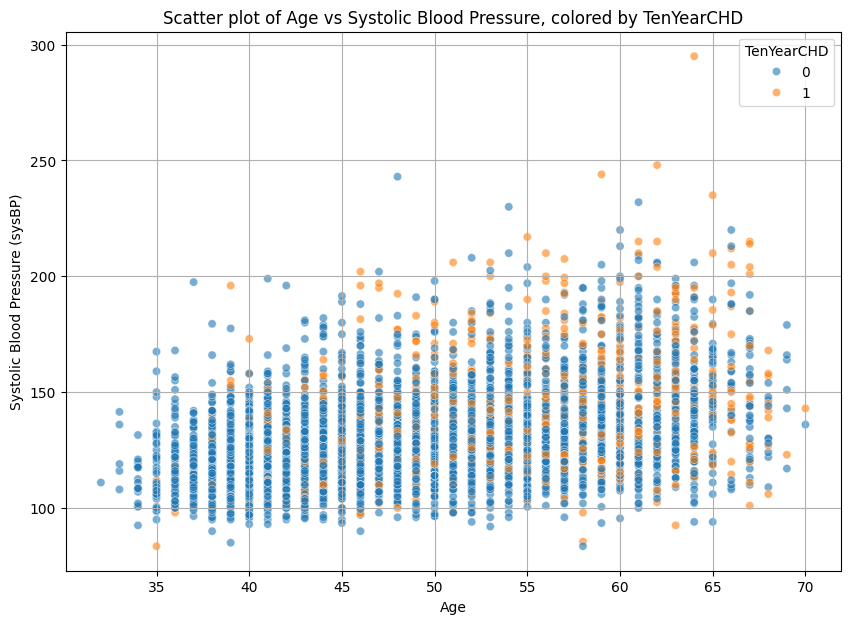

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='age', y='sysBP', hue='TenYearCHD', alpha=0.6)
plt.title('Scatter plot of Age vs Systolic Blood Pressure, colored by TenYearCHD')
plt.xlabel('Age')
plt.ylabel('Systolic Blood Pressure (sysBP)')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score


In [ ]:
from sklearn.model_selection import train_test_split

# Handle missing values by dropping rows with NaNs. This is a common and simple approach
# but more sophisticated imputation methods could be used depending on the analysis requirements.
df_cleaned = df.dropna()

# Define features (X) and target (y)
# 'TenYearCHD' is assumed to be the target variable indicating a 10-year risk of coronary heart disease.
X = df_cleaned.drop('TenYearCHD', axis=1)
y = df_cleaned['TenYearCHD']

# Apply train-test split
# test_size=0.2 means 20% of data will be used for testing, 80% for training
# random_state ensures reproducibility of the split, meaning you get the same split every time you run it
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {x_train.shape}")
print(f"Shape of X_test: {x_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (2924, 15)
Shape of X_test: (732, 15)
Shape of y_train: (2924,)
Shape of y_test: (732,)


In [ ]:
lr=LogisticRegression

In [ ]:
# Re-instantiate LogisticRegression as an object (as it was previously assigned as the class)
lr = LogisticRegression(random_state=42, solver='liblinear') # Added random_state for reproducibility and solver for stability

# Train the Logistic Regression model using the fit method
lr.fit(x_train, y_train)

LogisticRegression(random_state=42, solver='liblinear')

In [ ]:
pre=lr.predict(x_test)

In [ ]:
accuracy_score(y_test,pre)

0.8333333333333334

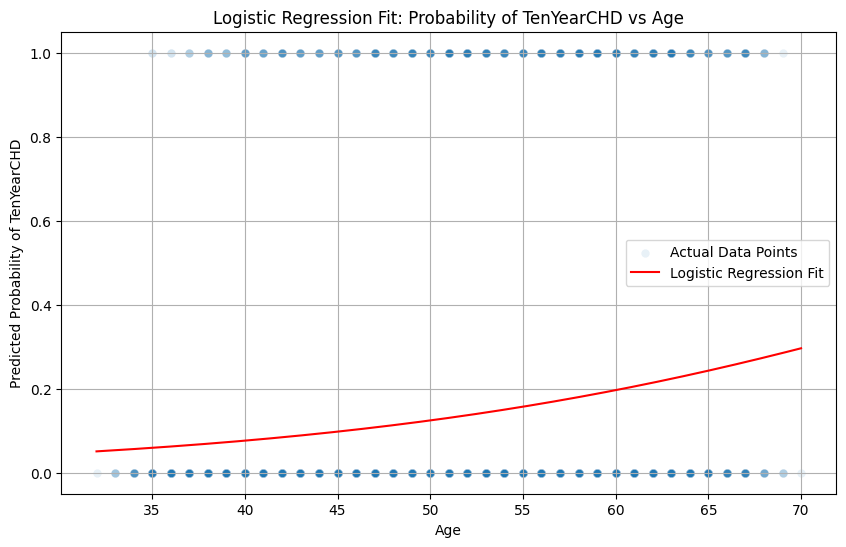

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported

# Create a range of age values for plotting
age_range = np.linspace(X['age'].min(), X['age'].max(), 300)

# Get the mean of all features in X
mean_features = X.mean()

# Create a single-row DataFrame from the mean features
mean_df_row = pd.DataFrame([mean_features.values], columns=X.columns)

# Repeat this single row to create dummy_X with the length of age_range
dummy_X = pd.concat([mean_df_row]*len(age_range), ignore_index=True)

# Now, vary only the 'age' feature in dummy_X
dummy_X['age'] = age_range

# Predict probabilities for the dummy data
# We need the probability of the positive class (TenYearCHD=1)
probabilities = lr.predict_proba(dummy_X)[:, 1]

# Plotting the logistic fit line
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X['age'], y=y, alpha=0.1, label='Actual Data Points')
plt.plot(age_range, probabilities, color='red', label='Logistic Regression Fit')

plt.title('Logistic Regression Fit: Probability of TenYearCHD vs Age')
plt.xlabel('Age')
plt.ylabel('Predicted Probability of TenYearCHD')
plt.legend()
plt.grid(True)
plt.show()

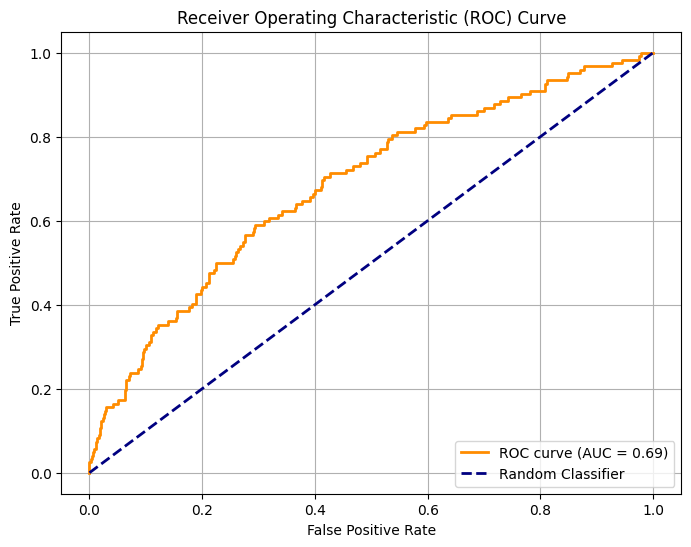

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# Get predicted probabilities for the positive class (TenYearCHD=1)
y_pred_proba = lr.predict_proba(x_test)[:, 1]

# Calculate ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate Area Under the Curve (AUC)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

The ROC curve helps evaluate the model's ability to discriminate between classes. A higher AUC (Area Under the Curve) generally indicates a better performing model. Now, let's look at the Confusion Matrix to see the types of correct and incorrect predictions.

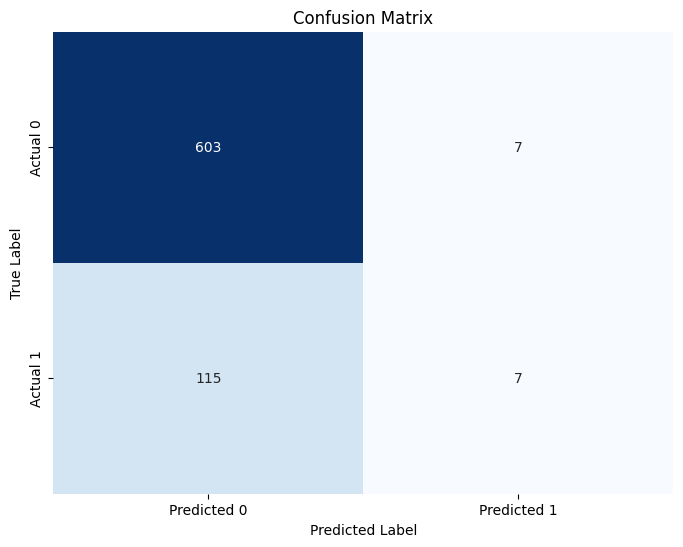

In [ ]:
# Calculate the confusion matrix
cm = confusion_matrix(y_test, pre)

# Display the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

" Code from Scratch"


In [ ]:
import numpy as np # Ensure numpy is imported for numerical operations
from sklearn.metrics import accuracy_score # Import accuracy_score for tracking

class LogisticRegressionScratch:
    def __init__(self, lr=0.5, n_iterations=4000):
        self.lr = lr
        self.n_iterations = n_iterations
        self.weights = None
        self.history = {'accuracy': [], 'iterations': []} # Added history attribute

    def _sigmoid(self, z):
        # Corrected sigmoid formula from 1/1+np.exp(-z) to 1 / (1 + np.exp(-z))
        # Using np.clip to prevent overflow with large negative numbers
        z = np.clip(z, -500, 500) # Clip values to avoid exp overflow/underflow
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        X_b = np.insert(X, 0, 1, axis=1)
        n_samples, n_features = X_b.shape
        self.weights = np.zeros(n_features)

        for i in range(self.n_iterations):
            linear_model = np.dot(X_b, self.weights)
            y_predicted = self._sigmoid(linear_model)
            gradient = (1/n_samples) * np.dot(X_b.T, (y_predicted - y))
            self.weights -= self.lr * gradient

            # Record accuracy every 100 iterations
            if i % 100 == 0:
                y_train_pred = self.predict(X)
                train_accuracy = accuracy_score(y, y_train_pred)
                self.history['accuracy'].append(train_accuracy)
                self.history['iterations'].append(i)

        return self.weights[0], self.weights[1:]

    def predict_proba(self, X):
        X_b = np.insert(X, 0, 1, axis=1)
        linear_model = np.dot(X_b, self.weights)
        return self._sigmoid(linear_model)

    def predict(self, X, threshold=0.5):
        probabilities = self.predict_proba(X)
        return (probabilities >= threshold).astype(int)

In [ ]:
import kagglehub
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.


In [ ]:
import os
import pandas as pd

# List contents of the downloaded path to find the CSV file
file_list = os.listdir(path)
print(f"Files in the downloaded directory: {file_list}")

# Assuming the CSV file is named 'data.csv' based on typical Kaggle datasets or previous interaction.
# If there are multiple CSVs, this might need manual adjustment.
# For 'breast-cancer-wisconsin-data', the main file is often 'data.csv'
cancer_csv_file_name = 'data.csv'
full_cancer_csv_path = os.path.join(path, cancer_csv_file_name)

# Load the data into a new pandas DataFrame called df_cancer
df_cancer = pd.read_csv(full_cancer_csv_path)

# Display the first 5 rows of the DataFrame
display(df_cancer.head())

Files in the downloaded directory: ['data.csv']


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
from sklearn.preprocessing import StandardScaler

# Drop unnecessary columns from df_cancer
# 'id' is just an identifier, 'Unnamed: 32' is an empty column
X_cancer = df_cancer.drop(['id', 'diagnosis', 'Unnamed: 32'], axis=1)
y_cancer = df_cancer['diagnosis']

# Encode the target variable 'diagnosis' (M=1, B=0)
y_cancer = y_cancer.map({'M': 1, 'B': 0})

# Split the cancer data into training and testing sets
x_cancer_train, x_cancer_test, y_cancer_train, y_cancer_test = train_test_split(X_cancer, y_cancer, test_size=0.2, random_state=42)

# Initialize and fit StandardScaler
scaler = StandardScaler()
x_cancer_train_scaled = scaler.fit_transform(x_cancer_train)
x_cancer_test_scaled = scaler.transform(x_cancer_test)

print(f"Shape of x_cancer_train_scaled: {x_cancer_train_scaled.shape}")
print(f"Shape of x_cancer_test_scaled: {x_cancer_test_scaled.shape}")

# Instantiate and train the custom Logistic Regression model
# Using the same learning rate and iterations as defined in the class for now.
custom_lr_cancer = LogisticRegressionScratch(lr=0.5, n_iterations=4000)

# The fit method in LogisticRegressionScratch currently returns bias and weights.
# We will call it to set internal weights.
custom_lr_cancer.fit(x_cancer_train_scaled, y_cancer_train.values)

# Make predictions on the test set
y_cancer_pred = custom_lr_cancer.predict(x_cancer_test_scaled)

# Calculate accuracy
custom_cancer_accuracy = accuracy_score(y_cancer_test, y_cancer_pred)
print(f"Custom Logistic Regression Accuracy on Breast Cancer data: {custom_cancer_accuracy}")

Shape of x_cancer_train_scaled: (455, 30)
Shape of x_cancer_test_scaled: (114, 30)
Custom Logistic Regression Accuracy on Breast Cancer data: 0.9736842105263158


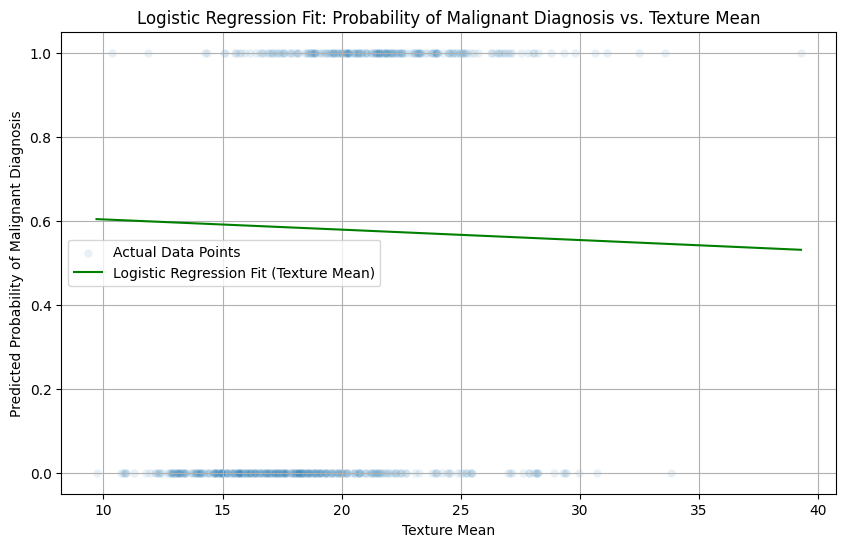

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Create a range of 'texture_mean' values for plotting
texture_mean_range = np.linspace(X_cancer['texture_mean'].min(), X_cancer['texture_mean'].max(), 300)

# Get the mean of all features in X_cancer
mean_cancer_features = X_cancer.mean()

# Create a single-row DataFrame from the mean features
mean_cancer_df_row_texture = pd.DataFrame([mean_cancer_features.values], columns=X_cancer.columns)

# Repeat this single row to create dummy_X_cancer_texture with the length of texture_mean_range
dummy_X_cancer_texture = pd.concat([mean_cancer_df_row_texture] * len(texture_mean_range), ignore_index=True)

# Now, vary only the 'texture_mean' feature in dummy_X_cancer_texture
dummy_X_cancer_texture['texture_mean'] = texture_mean_range

# IMPORTANT: Scale the dummy_X_cancer_texture data using the same scaler fitted on the training data
# We need to ensure the column order is consistent with the scaler's fitted order
dummy_X_cancer_texture_scaled = scaler.transform(dummy_X_cancer_texture)

# Predict probabilities for the scaled dummy data using the trained custom model
probabilities_cancer_texture = custom_lr_cancer_plot.predict_proba(dummy_X_cancer_texture_scaled)

# Plotting the logistic fit line for breast cancer data (texture_mean)
plt.figure(figsize=(10, 6))
# Scatter plot of actual data points (texture_mean vs. diagnosis)
sns.scatterplot(x=X_cancer['texture_mean'], y=y_cancer, alpha=0.1, label='Actual Data Points')
plt.plot(texture_mean_range, probabilities_cancer_texture, color='green', label='Logistic Regression Fit (Texture Mean)')

plt.title('Logistic Regression Fit: Probability of Malignant Diagnosis vs. Texture Mean')
plt.xlabel('Texture Mean')
plt.ylabel('Predicted Probability of Malignant Diagnosis')
plt.legend()
plt.grid(True)
plt.show()

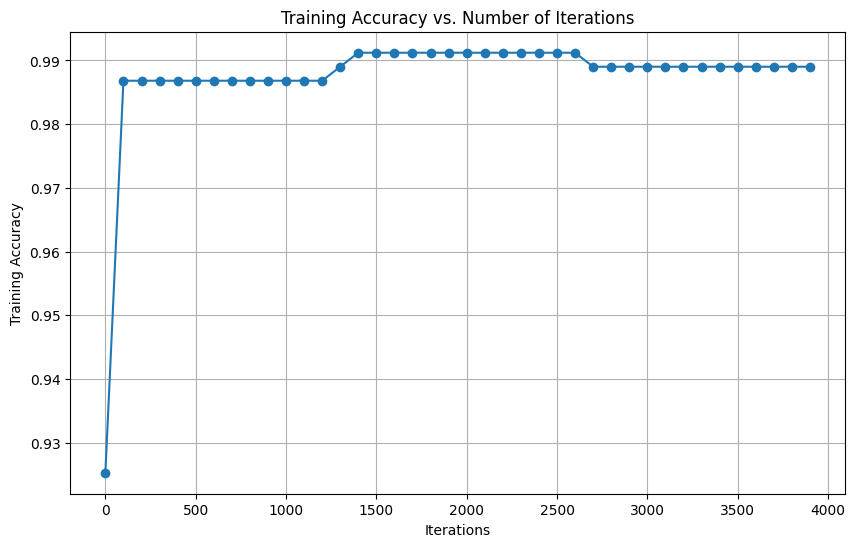

Final Custom Logistic Regression Accuracy on Breast Cancer data (after re-training for plot): 0.9736842105263158


In [ ]:
import matplotlib.pyplot as plt

# Re-instantiate and train the custom Logistic Regression model with history tracking
# It's important to re-instantiate so that the history is fresh for this run.
custom_lr_cancer_plot = LogisticRegressionScratch(lr=0.5, n_iterations=4000)

# Fit the model using the scaled training data
custom_lr_cancer_plot.fit(x_cancer_train_scaled, y_cancer_train.values)

# Plot the training accuracy vs. iterations
plt.figure(figsize=(10, 6))
plt.plot(custom_lr_cancer_plot.history['iterations'], custom_lr_cancer_plot.history['accuracy'], marker='o', linestyle='-')
plt.title('Training Accuracy vs. Number of Iterations')
plt.xlabel('Iterations')
plt.ylabel('Training Accuracy')
plt.grid(True)
plt.show()

# Optional: Print final accuracy after re-training
final_y_cancer_pred = custom_lr_cancer_plot.predict(x_cancer_test_scaled)
final_custom_cancer_accuracy = accuracy_score(y_cancer_test, final_y_cancer_pred)
print(f"Final Custom Logistic Regression Accuracy on Breast Cancer data (after re-training for plot): {final_custom_cancer_accuracy}")

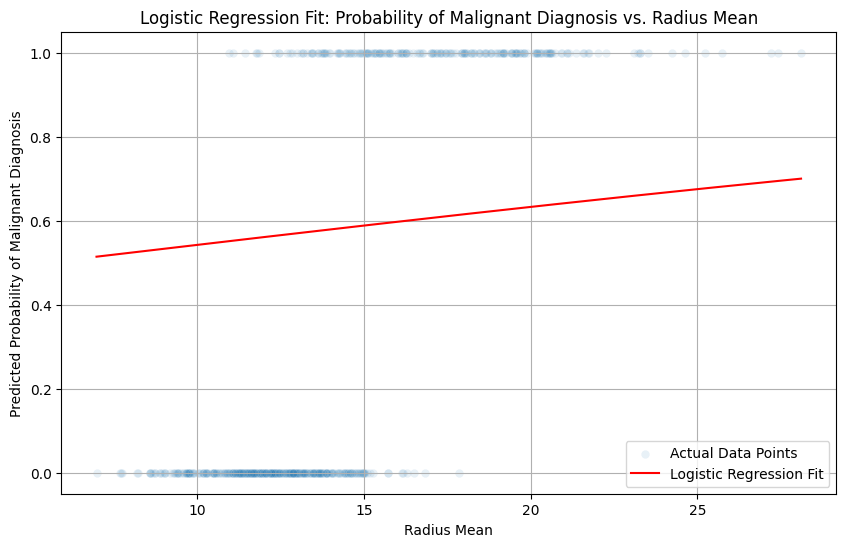

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Create a range of 'radius_mean' values for plotting
radius_mean_range = np.linspace(X_cancer['radius_mean'].min(), X_cancer['radius_mean'].max(), 300)

# Get the mean of all features in X_cancer
mean_cancer_features = X_cancer.mean()

# Create a single-row DataFrame from the mean features
mean_cancer_df_row = pd.DataFrame([mean_cancer_features.values], columns=X_cancer.columns)

# Repeat this single row to create dummy_X_cancer with the length of radius_mean_range
dummy_X_cancer = pd.concat([mean_cancer_df_row] * len(radius_mean_range), ignore_index=True)

# Now, vary only the 'radius_mean' feature in dummy_X_cancer
dummy_X_cancer['radius_mean'] = radius_mean_range

# IMPORTANT: Scale the dummy_X_cancer data using the same scaler fitted on the training data
# We need to ensure the column order is consistent with the scaler's fitted order
dummy_X_cancer_scaled = scaler.transform(dummy_X_cancer)

# Predict probabilities for the scaled dummy data using the trained custom model
probabilities_cancer = custom_lr_cancer_plot.predict_proba(dummy_X_cancer_scaled)

# Plotting the logistic fit line for breast cancer data
plt.figure(figsize=(10, 6))
# Scatter plot of actual data points (radius_mean vs. diagnosis)
sns.scatterplot(x=X_cancer['radius_mean'], y=y_cancer, alpha=0.1, label='Actual Data Points')
plt.plot(radius_mean_range, probabilities_cancer, color='red', label='Logistic Regression Fit')

plt.title('Logistic Regression Fit: Probability of Malignant Diagnosis vs. Radius Mean')
plt.xlabel('Radius Mean')
plt.ylabel('Predicted Probability of Malignant Diagnosis')
plt.legend()
plt.grid(True)
plt.show()

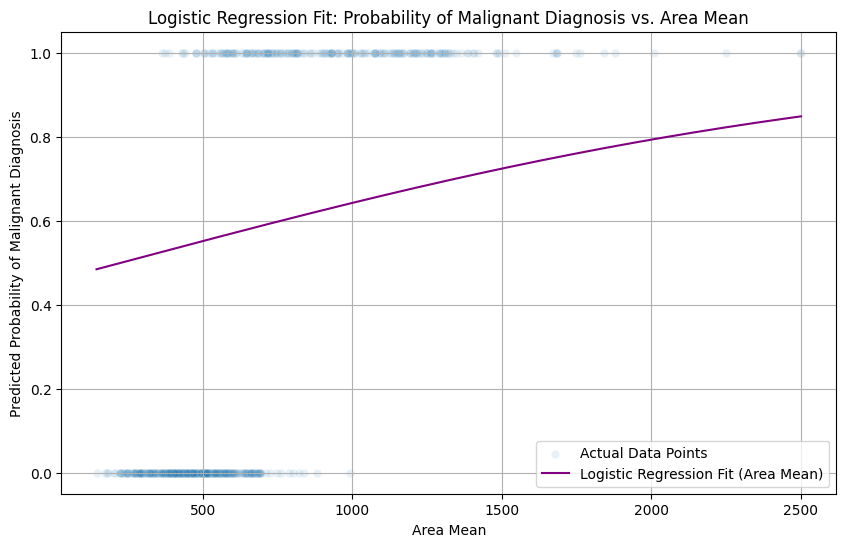

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Create a range of 'area_mean' values for plotting
area_mean_range = np.linspace(X_cancer['area_mean'].min(), X_cancer['area_mean'].max(), 300)

# Get the mean of all features in X_cancer
mean_cancer_features = X_cancer.mean()

# Create a single-row DataFrame from the mean features
mean_cancer_df_row_area = pd.DataFrame([mean_cancer_features.values], columns=X_cancer.columns)

# Repeat this single row to create dummy_X_cancer_area with the length of area_mean_range
dummy_X_cancer_area = pd.concat([mean_cancer_df_row_area] * len(area_mean_range), ignore_index=True)

# Now, vary only the 'area_mean' feature in dummy_X_cancer_area
dummy_X_cancer_area['area_mean'] = area_mean_range

# IMPORTANT: Scale the dummy_X_cancer_area data using the same scaler fitted on the training data
# We need to ensure the column order is consistent with the scaler's fitted order
dummy_X_cancer_area_scaled = scaler.transform(dummy_X_cancer_area)

# Predict probabilities for the scaled dummy data using the trained custom model
probabilities_cancer_area = custom_lr_cancer_plot.predict_proba(dummy_X_cancer_area_scaled)

# Plotting the logistic fit line for breast cancer data (area_mean)
plt.figure(figsize=(10, 6))
# Scatter plot of actual data points (area_mean vs. diagnosis)
sns.scatterplot(x=X_cancer['area_mean'], y=y_cancer, alpha=0.1, label='Actual Data Points')
plt.plot(area_mean_range, probabilities_cancer_area, color='purple', label='Logistic Regression Fit (Area Mean)')

plt.title('Logistic Regression Fit: Probability of Malignant Diagnosis vs. Area Mean')
plt.xlabel('Area Mean')
plt.ylabel('Predicted Probability of Malignant Diagnosis')
plt.legend()
plt.grid(True)
plt.show()

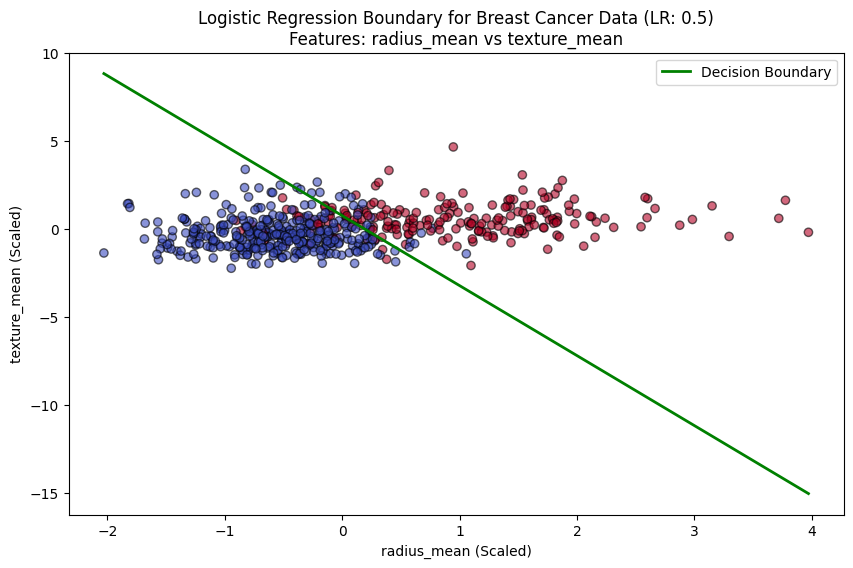

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import pandas as pd # Ensure pandas is imported to handle DataFrame/Series

# 3. Run your GD function (functions remain the same)
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def gd(X, y, lr=0.5, iters=4000): # Updated lr and iters for consistency with custom LR for cancer data
    X_inc = np.insert(X, 0, 1, axis=1)
    weights = np.zeros(X_inc.shape[1])
    n = X_inc.shape[0]

    for i in range(iters):
        y_hat = sigmoid(np.dot(X_inc, weights))
        # Ensure y is a numpy array for dot product, as it might be a pandas Series
        weights = weights + lr * (np.dot((y.values - y_hat), X_inc) / n)
    return weights[1:], weights[0]

# --- Apply Breast Cancer Data ---
# Select two features for visualization: 'radius_mean' and 'texture_mean'
X_viz_features = ['radius_mean', 'texture_mean']
X_cancer_viz = X_cancer[X_viz_features]

# 2. Scaling (Crucial for Gradient Descent)
# Use a new scaler instance for these two features
scaler_cancer_viz = StandardScaler()
X_cancer_viz_scaled = scaler_cancer_viz.fit_transform(X_cancer_viz)

# Run the GD function with the selected scaled breast cancer data
# Use y_cancer as the target variable
coef_cancer, intercept_cancer = gd(X_cancer_viz_scaled, y_cancer, lr=0.5, iters=4000)

# 4. Visualization
plt.figure(figsize=(10, 6))
# Scatter plot of the two selected scaled features, colored by actual diagnosis
plt.scatter(X_cancer_viz_scaled[:, 0], X_cancer_viz_scaled[:, 1], c=y_cancer, cmap='coolwarm', edgecolors='k', alpha=0.6)

# Calculate the decision boundary line
# Formula: w1*x1 + w2*x2 + b = 0  =>  x2 = -(w1*x1 + b) / w2
x_values_cancer = np.array([np.min(X_cancer_viz_scaled[:, 0]), np.max(X_cancer_viz_scaled[:, 0])])
y_values_cancer = -(coef_cancer[0] * x_values_cancer + intercept_cancer) / coef_cancer[1]

plt.plot(x_values_cancer, y_values_cancer, label='Decision Boundary', color='green', linewidth=2)
plt.title(f"Logistic Regression Boundary for Breast Cancer Data (LR: 0.5)\nFeatures: {X_viz_features[0]} vs {X_viz_features[1]}")
plt.xlabel(f"{X_viz_features[0]} (Scaled)")
plt.ylabel(f"{X_viz_features[1]} (Scaled)")
plt.legend()
plt.show()

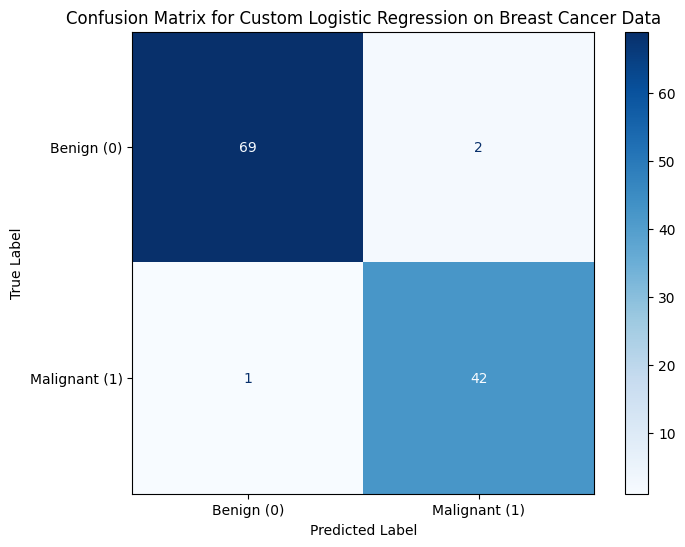

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Make predictions on the scaled test data using the custom model
y_cancer_pred_custom = custom_lr_cancer_plot.predict(x_cancer_test_scaled)

# Calculate the confusion matrix for the custom model
cm_cancer_custom = confusion_matrix(y_cancer_test, y_cancer_pred_custom)

# Display the confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=cm_cancer_custom, display_labels=['Benign (0)', 'Malignant (1)']).plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix for Custom Logistic Regression on Breast Cancer Data')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.grid(False) # Turn off grid for ConfusionMatrixDisplay
plt.show()